In [20]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from lmpy import lm, lme, gam
from lmpy.data import data
from lmpy.compare import anova, AIC, BIC
from lmpy.plot import pairs

### 1.1.2

In [21]:
hubble = data("hubble", "gamair")
hubble.head()

Galaxy,y,x
enum,i64,f64
"""NGC0300""",133,2.0
"""NGC0925""",664,9.16
"""NGC1326A""",1794,16.14
"""NGC1365""",1594,17.95
"""NGC1425""",1473,21.88


In [22]:
m_hub = lm('y ~ x - 1', data = hubble)
m_hub.summary()

Formula: y ~ x - 1

Residuals:
    Min      1Q Median     3Q    Max
-736.49 -132.52 -19.00 172.18 557.98

Coefficients:
   Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
x    76.581       3.965     68.38      84.78    19.32  1.03e-15  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 24, p = 1, Residual SE = 258.933 on 23 DF
R-Squared = 0.9419, adjusted R-Squared = 0.9394
F-statistics = 373.0807 on 1 and 23 DF, p-value: 1.031907e-15

Log Likelihood = -166.9015, AIC = 337.8030, BIC = 340.1591


In [23]:
m_hub_no_outliers = lm('y ~ x - 1', data = hubble.filter(np.ravel(np.abs(m_hub.residuals)<300)))
m_hub_no_outliers.summary()

Formula: y ~ x - 1

Residuals:
    Min      1Q Median     3Q    Max
-304.25 -141.94 -26.50 138.26 269.78

Coefficients:
   Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
x    77.673       2.970     71.50      83.85    26.15    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 22, p = 1, Residual SE = 180.464 on 21 DF
R-Squared = 0.9702, adjusted R-Squared = 0.9688
F-statistics = 683.8241 on 1 and 21 DF, p-value: 1.659996e-17

Log Likelihood = -145.0066, AIC = 294.0132, BIC = 296.1953


Text(0.5, 0.98, 'm_hub vs. m_hub_no_outliers')

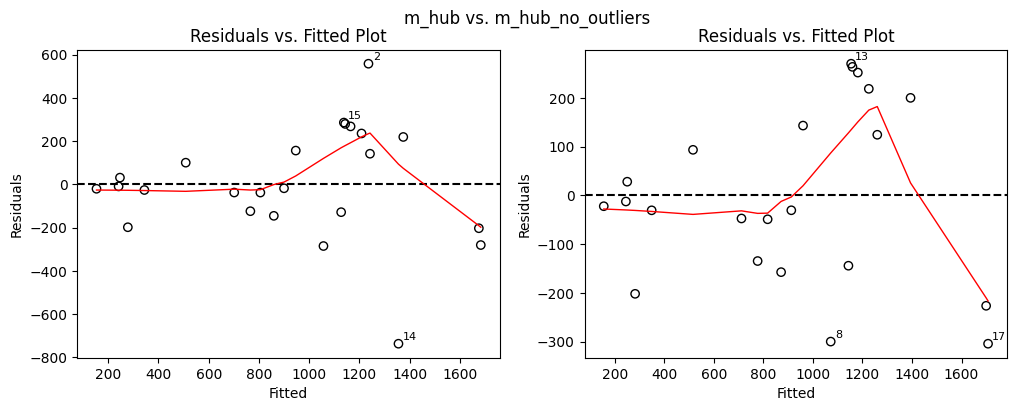

In [24]:
fig, ax = plt.subplots(1,2, figsize=(12, 4))
m_hub.plot_residuals(ax=ax[0])
m_hub_no_outliers.plot_residuals(ax=ax[1])
fig.suptitle("m_hub vs. m_hub_no_outliers")

### 1.5

In [25]:
sperm = data("sperm.comp1", "gamair")
sperm.head()

subject,time.ipc,prop.partner,count
enum,i64,f64,i64
"""A""",60,0.2,570
"""B""",149,0.98,219
"""D""",70,0.5,485
"""F""",168,0.5,516
"""K""",48,0.2,448


array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

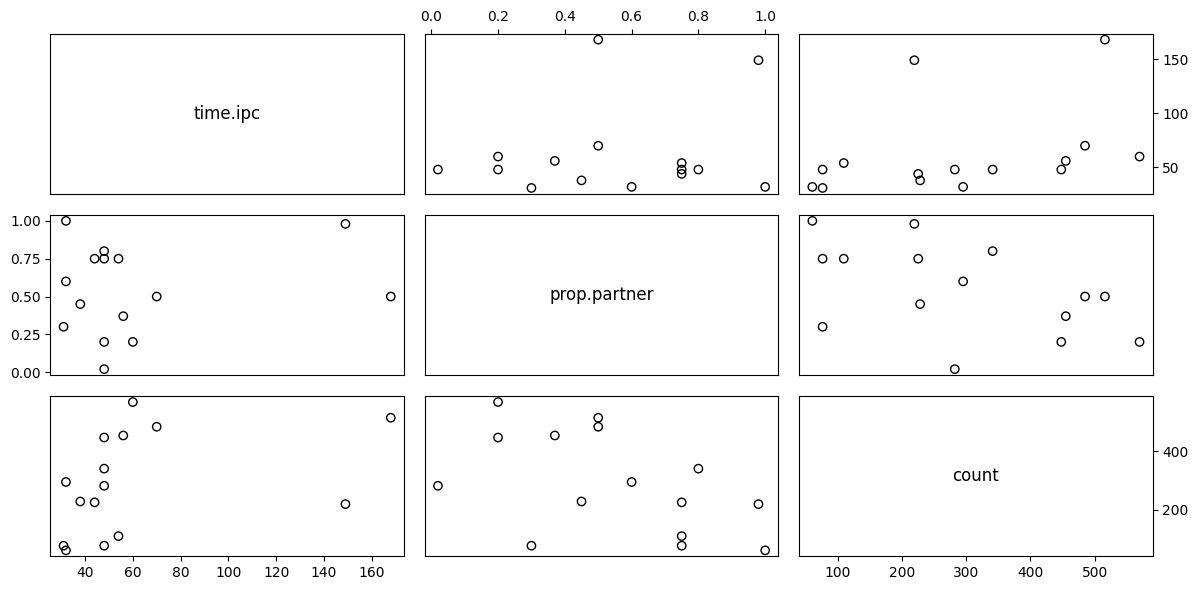

In [26]:
pairs(sperm, figsize=(12,6))

In [27]:
m1_sc = lm("count ~ time.ipc + prop.partner", data=sperm)
m1_sc.summary()

Formula: count ~ time.ipc + prop.partner

Residuals:
     Min      1Q Median     3Q     Max
-239.740 -96.772  2.171 96.837 163.997

Coefficients:
               Estimate  Std. Error    CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    357.4184     88.0822   165.50390  549.33297    4.058   0.00159  **
time.ipc         1.9416      0.9067    -0.03395    3.91717    2.141   0.05346  .
prop.partner  -339.5602    126.2535  -614.64282  -64.47752   -2.690   0.01969  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 3, Residual SE = 136.609 on 12 DF
R-Squared = 0.4573, adjusted R-Squared = 0.3669
F-statistics = 5.0562 on 2 and 12 DF, p-value: 0.03

Log Likelihood = -93.3673, AIC = 194.7346, BIC = 197.5668


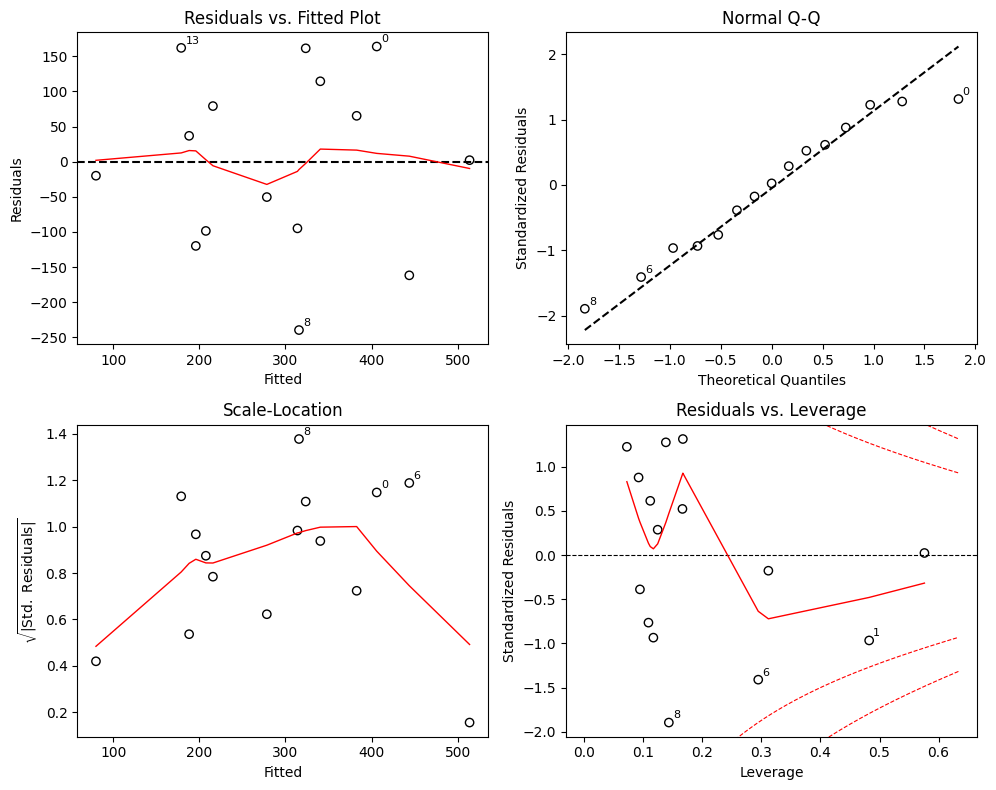

In [28]:
m1_sc.plot()

In [29]:
m1_sc.X

(Intercept),time.ipc,prop.partner
f64,f64,f64
1.0,60.0,0.2
1.0,149.0,0.98
1.0,70.0,0.5
1.0,168.0,0.5
1.0,48.0,0.2
…,…,…
1.0,48.0,0.75
1.0,54.0,0.75
1.0,32.0,0.6


In [30]:
m2_sc = lm('count ~ time.ipc + I(prop.partner * time.ipc)', data=sperm)
m2_sc.summary()

Formula: count ~ time.ipc + I(prop.partner * time.ipc)

Residuals:
    Min      1Q Median     3Q    Max
-187.68 -110.54  18.12 101.95 158.20

Coefficients:
                            Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)                  140.470      64.063    0.8892   280.0506    2.193   0.04877  *
time.ipc                       5.618       1.549    2.2420     8.9936    3.626   0.00348  **
I(prop.partner * time.ipc)    -5.478       1.741   -9.2714    -1.6845   -3.146   0.00843  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 3, Residual SE = 128.023 on 12 DF
R-Squared = 0.5234, adjusted R-Squared = 0.4440
F-statistics = 6.5888 on 2 and 12 DF, p-value: 0.01

Log Likelihood = -92.3937, AIC = 192.7874, BIC = 195.6196


In [31]:
m3_sc = lm('count ~ prop.partner', data=sperm)
m3_sc.summary()

Formula: count ~ prop.partner

Residuals:
    Min      1Q Median     3Q    Max
-287.83 -111.30  18.84 117.45 210.61

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)     451.50       86.23    265.22     637.79    5.236  0.000161  ***
prop.partner   -292.23      140.40   -595.56      11.09   -2.081  0.057727  .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 2, Residual SE = 154.301 on 13 DF
R-Squared = 0.2500, adjusted R-Squared = 0.1923
F-statistics = 4.3322 on 1 and 13 DF, p-value: 0.06

Log Likelihood = -95.7944, AIC = 197.5889, BIC = 199.7130


In [32]:
m4_sc = lm('count ~ 1', data=sperm)
AIC(m1_sc, m3_sc, m4_sc)

       df     AIC
m1_sc   4  194.73
m3_sc   3  197.59
m4_sc   2  199.90


### 2.5.4 + 2.5.5

In [33]:
Machines = data("Machines", "nlme")
Machines

Worker,Machine,score
enum,enum,f64
"""1""","""A""",52.0
"""1""","""A""",52.8
"""1""","""A""",53.1
"""2""","""A""",51.8
"""2""","""A""",52.8
…,…,…
"""5""","""C""",72.0
"""5""","""C""",71.1
"""6""","""C""",62.0


In [34]:

a1 = lme('score ~ Machine + (1|Worker) + (1|Worker:Machine)', data=Machines)
a2 = lme('score ~ Machine + (1|Worker) + (Machine-1|Worker)', data=Machines)
AIC(a1,a2)


    df     AIC
a1   6  227.69
a2  11  230.31


In [35]:
anova(a1, a2)

refitting model(s) with ML (instead of REML)
Analysis of Variance Table (likelihood ratio test)

a1: score ~ Machine + (1|Worker) + (1|Worker:Machine)
a2: score ~ Machine + (1|Worker) + (Machine-1|Worker)

    npar       AIC       BIC     logLik  deviance   Chisq  Df  Pr(>Chisq)
a1     6  237.2695  249.2034  -112.6347  225.2695
a2    11  238.4181  260.2969  -108.2090  216.4181  8.8514   5      0.1151
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [36]:
b1 = gam('score ~ Machine + s(Worker, bs="re") + s(Machine, Worker, bs="re")', data=Machines, method='REML')
b1.vcomp


name,std_dev,lower,upper
str,f64,f64,f64
"""s(Worker)""",4.781051,2.249858,10.15995
"""s(Machine,Worker)""",3.729538,2.382816,5.837404
"""scale""",0.961577,0.763254,1.211432


In [37]:
b2 = gam('score ~ Machine + s(Worker,bs="re") + s(Worker,bs="re",by=Machine)',data=Machines, method='REML')
b2.vcomp

name,std_dev,lower,upper
str,f64,f64,f64
"""s(Worker)""",3.785947,1.798732,7.968613
"""s(Worker):MachineA""",1.940322,0.253188,14.869794
"""s(Worker):MachineB""",5.874023,2.988334,11.546281
"""s(Worker):MachineC""",2.84547,0.829933,9.75585
"""scale""",0.961577,0.763254,1.211432


In [38]:
AIC(b1, b2)

           df     AIC
b1  18.859954  165.19
b2  18.985573  165.62


### 4.6

In [39]:
trees = data("trees", "mgcv")

In [40]:
from lmpy.family import Gamma
ct1 = gam('Volume ~ s(Height) + s(Girth)', family=Gamma(link="log"), data=trees)
ct1.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height) + s(Girth)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27570     0.01492    219.6    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf  Ref.df       F   p-value
s(Height)  1.000   1.000   31.32  6.51e-06  ***
s(Girth)   2.422   3.044  219.28   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.973  Deviance explained = 97.8%
GCV = 0.0080824  Scale est. = 0.006899  n = 31


### 7.2

In [41]:
brain = data("brain", "gamair")
brain = brain.filter(pl.col("medFPQ") > 5e-3)

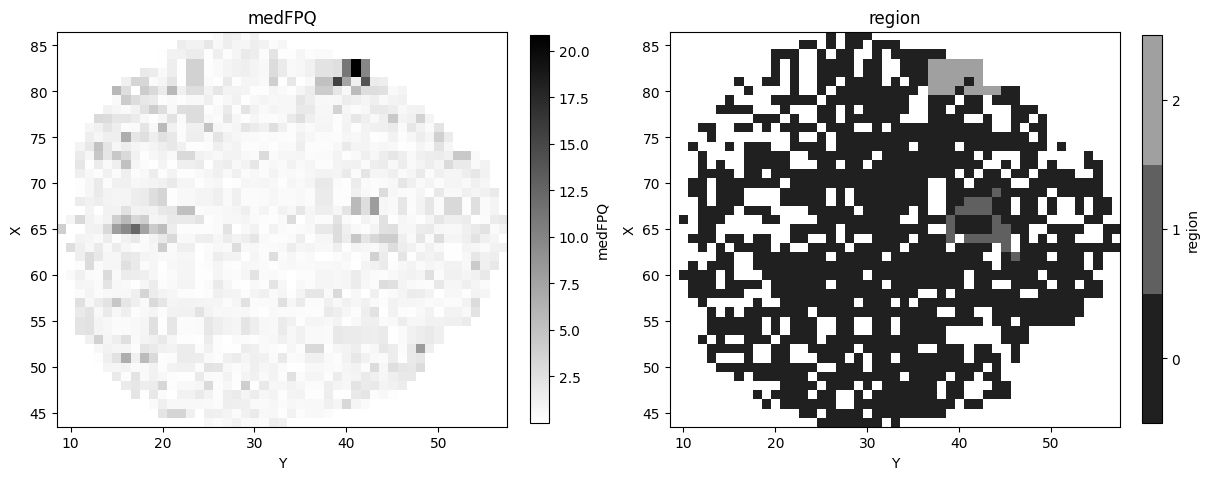

In [42]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X_min, X_max = brain["X"].min(), brain["X"].max()
Y_min, Y_max = brain["Y"].min(), brain["Y"].max()
nx = X_max - X_min + 1
ny = Y_max - Y_min + 1

medFPQ = np.full((nx, ny), np.nan)   # rows=X, cols=Y
region = np.full((nx, ny), np.nan)
for row in brain.iter_rows(named=True):
    i = row["X"] - X_min   # row index = X
    j = row["Y"] - Y_min   # col index = Y
    medFPQ[i, j] = row["medFPQ"]
    if row["region"] is not None:
        region[i, j] = row["region"]

extent = (Y_min - 0.5, Y_max + 0.5, X_min - 0.5, X_max + 0.5)  # (left, right, bottom, top)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axes[0].imshow(medFPQ, origin="lower", cmap="gray_r",
                     aspect="equal", extent=extent)
fig.colorbar(im0, ax=axes[0], label="medFPQ", shrink=0.8)
axes[0].set(xlabel="Y", ylabel="X", title="medFPQ")

cmap_reg = ListedColormap(["#202020", "#606060", "#A0A0A0"])
im1 = axes[1].imshow(region, origin="lower", cmap=cmap_reg,
                     aspect="equal", vmin=-0.5, vmax=2.5, extent=extent)
fig.colorbar(im1, ax=axes[1], ticks=[0, 1, 2],
             label="region", shrink=0.8)
axes[1].set(xlabel="Y", ylabel="X", title="region")
plt.show()

In [43]:
m0 = gam('medFPQ ~ s(Y, X, k=100)', data=brain)
m1 = gam('medFPQ^.25 ~ s(Y, X, k=100)', data=brain)
m2 = gam('medFPQ ~ s(Y, X, k=100)', data=brain, family=Gamma(link="log"))
m3 = gam('medFPQ ~ s(Y,k=30) + s(X,k=30)', data=brain, family=Gamma(link="log"))

tm = gam('medFPQ ~ te(Y, X, k=10)', data=brain, family=Gamma(link="log"))

# (d) main effects + interaction, estimated separately
tm1 = gam('medFPQ ~ s(Y, k=10, bs="cr") + s(X, k=10, bs="cr") + ti(Y, X, k=10)',
          data=brain, family=Gamma(link="log"))

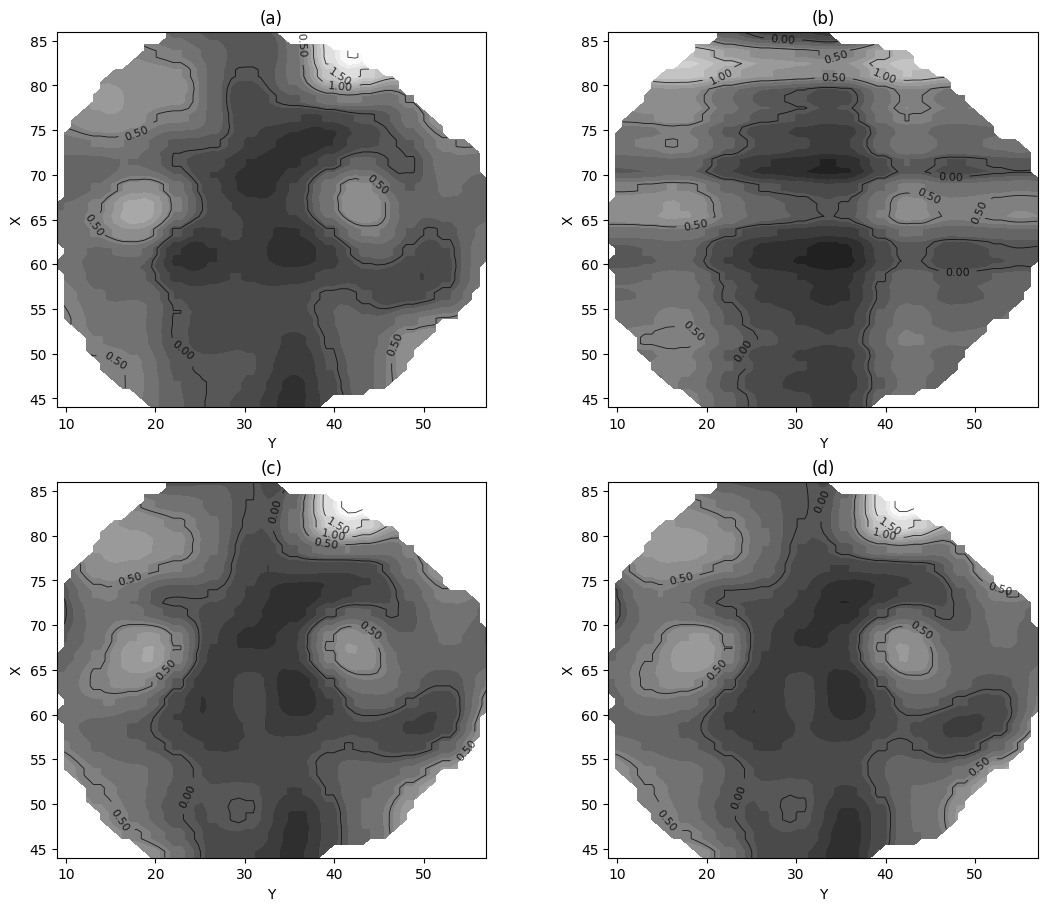

In [44]:
fig, axes = plt.subplot_mosaic(
    [["a", "b"],
     ["c", "d"]],
    figsize=(11, 9),
    constrained_layout=True,
)
for label, m in zip("abcd", [m2, m3, tm, tm1]):
    m.vis(view=("Y", "X"), too_far=0.03, n_grid=60).plot(
        kind="contour",
        ax=axes[label],
        cmap="gray",
        levels=np.linspace(-1, 2, 20),
        contour_levels=np.linspace(0, 2, 5),
        colorbar=False,
        clabel=True,
    )
    axes[label].set_title(f"({label})")
plt.show()